In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
k = 25585.5
CO = 140.4 #25600CE strike
PO = 162.25 #25600PE strike
f = k+(CO-PO)
print(f)

25563.65


In [ ]:
# --- 1. PARAMETERS ---
S0 = 	f     # Current Nifty 50 Index Value
K = 25850       # Strike Price (The bet)
T = 7 / 365    # Time to expiry (7 days expressed in years)
r = 0.07         # Set to 0 (Price is already forward-adjusted)
sigma = 0.085    # Volatility IV(8.5%)

# Simulation Settings
M = 50          # Number of time steps (trading days in the simulation)
I = 500000      # Number of simulation paths (universes)

In [ ]:
# --- 2. SIMULATION (Antithetic Variates) ---
# We divide the total time T into M small steps
dt = T / M
# We calculate half the paths, then mirror them
I_half = 50000

# Generate random numbers for half the paths
z_half = np.random.standard_normal((M + 1, I_half))

# Create the full 'z' by combining z and -z
# This forces the mean of random numbers to be EXACTLY 0
z = np.concatenate((z_half, -z_half), axis=1)

# Now 'z' has shape (M+1, 100000) just like before, but perfectly balanced
drift = (r - 0.5 * sigma ** 2) * dt
shock = sigma * np.sqrt(dt) * z

S = S0 * np.exp(np.cumsum(drift + shock, axis=0))
S[0] = S0

In [ ]:
# --- 3. VALUATION ---
# Get the final price (at the end of 30 days) for all 100,000 paths
S_final = S[-1]

# Calculate Payoff for Call Option: Max(S_final - K, 0)
# We use np.maximum to do this element-wise
payoff = np.maximum(S_final - K, 0)

# The Option Price is the Average Payoff discounted back to today
C0 = np.exp(-r * T) * np.mean(payoff)

print(f"Theoretical Call Option Price: ₹{C0:.2f}")

Theoretical Call Option Price: ₹35.02


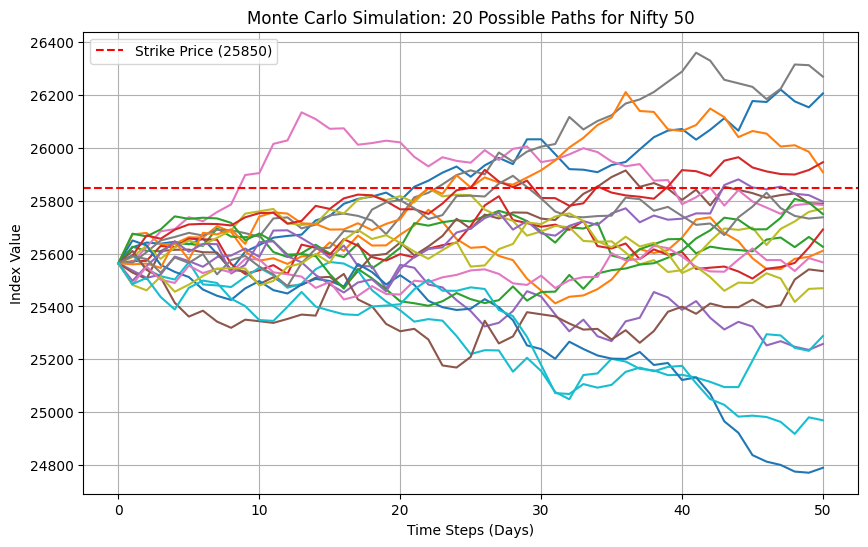

In [ ]:

# --- 4. VISUALIZATION ---
plt.figure(figsize=(10, 6))
# Plot only the first 20 paths so the chart isn't messy
plt.plot(S[:, :20])
plt.grid(True)
plt.title(f'Monte Carlo Simulation: 20 Possible Paths for Nifty 50')
plt.xlabel('Time Steps (Days)')
plt.ylabel('Index Value')
plt.axhline(K, color='r', linestyle='--', label=f'Strike Price ({K})')
plt.legend()
plt.show()

In [ ]:
# Calculate Standard Deviation of the payoffs
std_dev = np.std(payoff)

# Calculate Standard Error (SE)
SE = std_dev / np.sqrt(I)

print(f"Model Price: ₹{C0:.2f}")
print(f"95% Confidence Interval: [₹{C0 - 1.96*SE:.2f}, ₹{C0 + 1.96*SE:.2f}]")

Model Price: ₹35.02
95% Confidence Interval: [₹34.76, ₹35.29]


In [ ]:
# --- IMPLIED VOLATILITY SOLVER ---

# 1. Define the Target (The Actual Market Price you see on screen)
market_price = 50.25  # <--- REPLACE THIS with the real Call Price

# 2. Iteration Loop
# We will start sigma at 10% and keep increasing it until the model matches the market
sigma_test = 0.10  # Start at 10%
model_price = 0

print(f"Target Market Price: {market_price}")
print("Searching for True Volatility...")

while model_price < market_price:
    # A. Update Sigma
    sigma_test += 0.001  # Increase by 0.1% each step

    # B. Run Quick Simulation (Vectorized)
    # Note: We use r=0, q=0 in drift because S0 is the Synthetic Forward
    drift = -0.5 * sigma_test ** 2 * dt
    shock = sigma_test * np.sqrt(dt) * z
    S = S0 * np.exp(np.cumsum(drift + shock, axis=0))
    S[0] = S0

    # C. Calculate Price
    payoff = np.maximum(S[-1] - K, 0)
    # Discounting: We still discount the cashflow by the Risk-Free Rate (7%)
    # Even though drift used r=0, money today is worth more than money in 7 days
    model_price = np.exp(-0.07 * T) * np.mean(payoff)

    # Optional: Print progress every 50 steps
    if int(sigma_test*1000) % 50 == 0:
        print(f"Trying Sigma: {sigma_test:.1%} -> Price: {model_price:.2f}")

print("-" * 30)
print(f"MATCH FOUND!")
print(f"True Implied Volatility: {sigma_test:.2%}")
print(f"Website IV: {sigma:.2%} (The website was underestimating volatility)")

Target Market Price: 50.25
Searching for True Volatility...
------------------------------
MATCH FOUND!
True Implied Volatility: 10.70%
Website IV: 8.50% (The website was underestimating volatility)
